##### 📌Labeling NLTK + SVC

In [ ]:
import pandas as pd
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from textblob import TextBlob

# Download lexicon untuk analisis sentimen
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\71478\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [84]:
# Load data
df_nltk = pd.read_csv("redmi6.csv", encoding='latin1')
df_nltk_clean = df_nltk.copy()

# Preprocessing kolom Rating & Date
df_nltk_clean['Rating'] = df_nltk_clean['Rating'].str.extract(r'(\d\.\d)').astype(float)
df_nltk_clean['Date'] = pd.to_datetime(df_nltk_clean['Date'].str.replace('on ', ''), errors='coerce')

# Tampilkan 10 baris pertama sebagai tabel
df_nltk.head(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful
5,Redmi 6 pro (3/32 GB) review after using for o...,Arun Yajurvedi,3.0 out of 5 stars,on 28 September 2018,Display,Over prised by at least around Rs.1000/- Low l...,2 people found this helpful
6,Fabulous!,Irukulla bharath,4.0 out of 5 stars,on 17 September 2018,Display,Pros:\nnotch display\nDual camera\nFace unlock...,3 people found this helpful
7,Fantastic,Amazon Customer,4.0 out of 5 stars,on 18 September 2018,Camera,Front camera is poor rest things are good,5 people found this helpful
8,Good,Amazon Customer,5.0 out of 5 stars,on 15 September 2018,Others,Wooo,5 people found this helpful
9,All youtubers are paid,Sharad,5.0 out of 5 stars,on 22 September 2018,Others,Realme is sub brand of oppo\nHe give money to ...,2 people found this helpful


In [ ]:
# Inisialisasi Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

# Hitung skor compound sentimen dari kolom Comments
df_nltk_clean['sentiment_score'] = df_nltk_clean['Comments'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])
# score dilihat dari nilai polarity, jika > 0.05 = positif, < 0.05 = negatif, 0.00 = netral

# Fungsi untuk memberi label berdasarkan skor
def label_sentiment(score):
    if score <= -0.05:
        return 0  # Negatif
    elif score >= 0.05:
        return 2  # Positif
    else:
        return 1  # Netral

# Terapkan pelabelan
df_nltk_clean['sentiment_label'] = df_nltk_clean['sentiment_score'].apply(label_sentiment)

# Fungsi mengubah label numerik ke teks
def label_to_text(label):
    if label == 0:
        return 'Negatif'
    elif label == 1:
        return 'Netral'
    elif label == 2:
        return 'Positif'

# Tambahkan kolom baru
df_nltk_clean['sentiment_label_text'] = df_nltk_clean['sentiment_label'].apply(label_to_text)

# Tampilkan 10 baris pertama dari kolom Comments dan hasil pelabelan sentimennya
df_nltk_clean[['Comments', 'sentiment_score', 'sentiment_label', 'sentiment_label_text']].head(20)

,Comments,sentiment_score,sentiment_label,sentiment_label_text
0,Another Midrange killer Smartphone by Xiaomi\n...,0.9981,2,Positif
1,All ok but vry small size mobile,0.1531,2,Positif
2,Quite good,0.4927,2,Positif
3,Redmi has always have been the the king of bud...,0.9610,2,Positif
4,worst product from MI. I am a hardcore fan of ...,-0.7677,0,Negatif
5,Over prised by at least around Rs.1000/- Low l...,0.9456,2,Positif
6,Pros:\nnotch display\nDual camera\nFace unlock...,0.8020,2,Positif
7,Front camera is poor rest things are good,-0.0516,0,Negatif
8,Wooo,0.0000,1,Netral
9,Realme is sub brand of oppo\nHe give money to ...,0.8970,2,Positif



Classification Report:
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         4
      Netral       1.00      0.20      0.33         5
     Positif       0.85      1.00      0.92        47

    accuracy                           0.86        56
   macro avg       0.62      0.40      0.42        56
weighted avg       0.81      0.86      0.80        56



c:\Users\71478\AppData\Local\anaconda3\envs\pyspark-311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\71478\AppData\Local\anaconda3\envs\pyspark-311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\71478\AppData\Local\anaconda3\envs\pyspark-311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

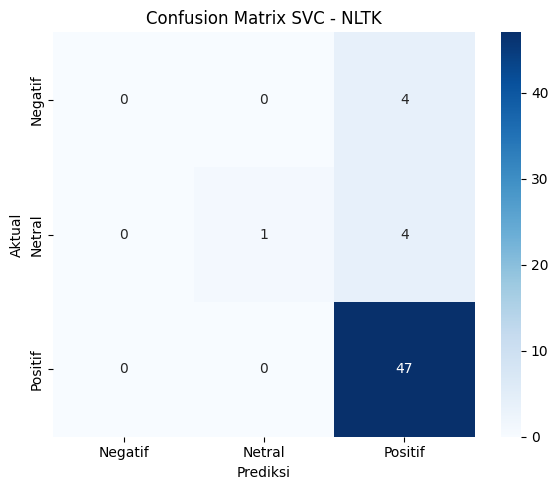

In [90]:
# Konversi teks menjadi fitur numerik
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X = tfidf.fit_transform(df_nltk_clean['Comments'].astype(str))
y = df_nltk_clean['sentiment_label']

# Split data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi dan latih model SVC
svc_model = SVC(kernel='linear', C=1.0)
svc_model.fit(X_train, y_train)

# Prediksi data uji
y_pred = svc_model.predict(X_test)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Netral', 'Positif']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVC - NLTK")
plt.tight_layout()
plt.show()

In [87]:
# Menampilkan 5 baris pertama dari semua kolom
df_nltk_clean.head(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,sentiment_score,sentiment_label,sentiment_label_text
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0,2018-10-01,Display,Another Midrange killer Smartphone by Xiaomi\n...,,0.9981,2,Positif
1,vry small size mobile,Raza ji,3.0,2018-09-15,Others,All ok but vry small size mobile,7 people found this helpful,0.1531,2,Positif
2,Full display not working in all application.,Vaibhav Patel,3.0,2018-09-18,Others,Quite good,7 people found this helpful,0.4927,2,Positif
3,Value for Money,Amazon Customer,5.0,2018-09-28,Display,Redmi has always have been the the king of bud...,2 people found this helpful,0.9610,2,Positif
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0,2018-09-18,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,-0.7677,0,Negatif
5,Redmi 6 pro (3/32 GB) review after using for o...,Arun Yajurvedi,3.0,2018-09-28,Display,Over prised by at least around Rs.1000/- Low l...,2 people found this helpful,0.9456,2,Positif
6,Fabulous!,Irukulla bharath,4.0,2018-09-17,Display,Pros:\nnotch display\nDual camera\nFace unlock...,3 people found this helpful,0.8020,2,Positif
7,Fantastic,Amazon Customer,4.0,2018-09-18,Camera,Front camera is poor rest things are good,5 people found this helpful,-0.0516,0,Negatif
8,Good,Amazon Customer,5.0,2018-09-15,Others,Wooo,5 people found this helpful,0.0000,1,Netral
9,All youtubers are paid,Sharad,5.0,2018-09-22,Others,Realme is sub brand of oppo\nHe give money to ...,2 people found this helpful,0.8970,2,Positif


In [93]:
# Melihat jumlah kategori unik pada kolom 'sentiment_label_text'
label_counts = df_nltk_clean['sentiment_label_text'].value_counts()

# Tampilkan hasil
print("📌Jumlah Masing-Masing Label pada Model NLTK:")
print(label_counts)

📌Jumlah Masing-Masing Label pada Model NLTK:
sentiment_label_text
Positif    214
Negatif     36
Netral      30
Name: count, dtype: int64


##### 📌Labeling TextBlob + SVC

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Load data
df_textblob = pd.read_csv("redmi6.csv", encoding='latin1')
df_textblob_clean = df_textblob.copy()

# Preprocessing kolom Rating & Date
df_textblob_clean['Rating'] = df_textblob_clean['Rating'].str.extract(r'(\d\.\d)').astype(float)
df_textblob_clean['Date'] = pd.to_datetime(df_textblob_clean['Date'].str.replace('on ', ''), errors='coerce')

df_textblob_clean.head(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0,2018-10-01,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0,2018-09-15,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0,2018-09-18,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0,2018-09-28,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0,2018-09-18,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful
5,Redmi 6 pro (3/32 GB) review after using for o...,Arun Yajurvedi,3.0,2018-09-28,Display,Over prised by at least around Rs.1000/- Low l...,2 people found this helpful
6,Fabulous!,Irukulla bharath,4.0,2018-09-17,Display,Pros:\nnotch display\nDual camera\nFace unlock...,3 people found this helpful
7,Fantastic,Amazon Customer,4.0,2018-09-18,Camera,Front camera is poor rest things are good,5 people found this helpful
8,Good,Amazon Customer,5.0,2018-09-15,Others,Wooo,5 people found this helpful
9,All youtubers are paid,Sharad,5.0,2018-09-22,Others,Realme is sub brand of oppo\nHe give money to ...,2 people found this helpful


In [155]:
# Tampilkan 10 baris pertama dari kolom Comments dan hasil pelabelan sentimennya
df_textblob_clean[['Comments', 'sentiment_score', 'sentiment_label', 'sentiment_label_text']].head(20)

,Comments,sentiment_score,sentiment_label,sentiment_label_text
0,Another Midrange killer Smartphone by Xiaomi\n...,0.238261,2,Positif
1,All ok but vry small size mobile,0.125000,1,Netral
2,Quite good,0.700000,2,Positif
3,Redmi has always have been the the king of bud...,0.143490,1,Netral
4,worst product from MI. I am a hardcore fan of ...,-0.800000,0,Negatif
5,Over prised by at least around Rs.1000/- Low l...,0.441176,2,Positif
6,Pros:\nnotch display\nDual camera\nFace unlock...,0.337500,2,Positif
7,Front camera is poor rest things are good,0.150000,1,Netral
8,Wooo,0.000000,1,Netral
9,Realme is sub brand of oppo\nHe give money to ...,0.300000,2,Positif



Classification Report:
              precision    recall  f1-score   support

     Negatif       1.00      0.25      0.40         4
      Netral       0.69      0.60      0.64        15
     Positif       0.86      0.97      0.91        37

    accuracy                           0.82        56
   macro avg       0.85      0.61      0.65        56
weighted avg       0.82      0.82      0.80        56



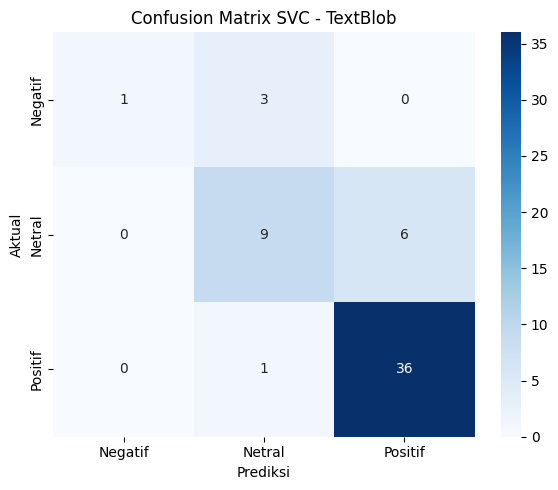

In [ ]:
# Hitung skor sentimen dari kolom Comments
def get_polarity(text):
    if pd.isnull(text) or text.strip() == "":
        return 0.0
    return TextBlob(text).sentiment.polarity

df_textblob_clean['sentiment_score'] = df_textblob_clean['Comments'].astype(str).apply(get_polarity)

# Labeling berdasarkan skor polaritas
def label_sentiment(score):
    if score <= -0.2:
        return 0  # Negatif
    elif score >= 0.2:
        return 2  # Positif
    else:
        return 1  # Netral

df_textblob_clean['sentiment_label'] = df_textblob_clean['sentiment_score'].apply(label_sentiment)

# Konversi label ke teks (seperti di NLTK)
def label_to_text(label):
    return ['Negatif', 'Netral', 'Positif'][label]

df_textblob_clean['sentiment_label_text'] = df_textblob_clean['sentiment_label'].apply(label_to_text)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X = tfidf.fit_transform(df_textblob_clean['Comments'].astype(str))
y = df_textblob_clean['sentiment_label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Inisialisasi dan latih model SVC
svc_model = SVC(kernel='linear', C=1.0)
svc_model.fit(X_train, y_train)

# Prediksi
y_pred = svc_model.predict(X_test)

# Evaluasi
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Netral', 'Positif']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVC - TextBlob")
plt.tight_layout()
plt.show()

In [72]:
# Tampilkan 10 baris pertama dari df_textblob_clean
df_textblob_clean.head(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,sentiment_score,sentiment_label,sentiment_label_text
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0,2018-10-01,Display,Another Midrange killer Smartphone by Xiaomi\n...,,0.238261,2,Positif
1,vry small size mobile,Raza ji,3.0,2018-09-15,Others,All ok but vry small size mobile,7 people found this helpful,0.125000,1,Netral
2,Full display not working in all application.,Vaibhav Patel,3.0,2018-09-18,Others,Quite good,7 people found this helpful,0.700000,2,Positif
3,Value for Money,Amazon Customer,5.0,2018-09-28,Display,Redmi has always have been the the king of bud...,2 people found this helpful,0.143490,1,Netral
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0,2018-09-18,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,-0.800000,0,Negatif
5,Redmi 6 pro (3/32 GB) review after using for o...,Arun Yajurvedi,3.0,2018-09-28,Display,Over prised by at least around Rs.1000/- Low l...,2 people found this helpful,0.441176,2,Positif
6,Fabulous!,Irukulla bharath,4.0,2018-09-17,Display,Pros:\nnotch display\nDual camera\nFace unlock...,3 people found this helpful,0.337500,2,Positif
7,Fantastic,Amazon Customer,4.0,2018-09-18,Camera,Front camera is poor rest things are good,5 people found this helpful,0.150000,1,Netral
8,Good,Amazon Customer,5.0,2018-09-15,Others,Wooo,5 people found this helpful,0.000000,1,Netral
9,All youtubers are paid,Sharad,5.0,2018-09-22,Others,Realme is sub brand of oppo\nHe give money to ...,2 people found this helpful,0.300000,2,Positif


In [92]:
# Hitung jumlah tiap label kategori (Positif, Netral, Negatif)
label_counts = df_textblob_clean['sentiment_label_text'].value_counts()

# Tampilkan hasilnya
print("📌Jumlah Masing-Masing Label pada Model TextBlob:")
print(label_counts)

📌Jumlah Masing-Masing Label pada Model TextBlob:
sentiment_label_text
Positif    187
Netral      73
Negatif     20
Name: count, dtype: int64


##### Labeling BERT + SVC

In [156]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification

              precision    recall  f1-score   support

     Negatif       0.56      0.91      0.69        11
      Netral       0.75      0.30      0.43        10
     Positif       0.94      0.91      0.93        35

    accuracy                           0.80        56
   macro avg       0.75      0.71      0.68        56
weighted avg       0.83      0.80      0.79        56



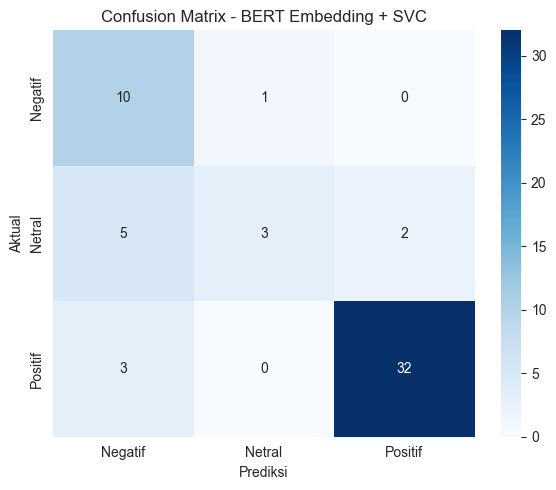

In [157]:
# Load data
df_bert = pd.read_csv("redmi6.csv", encoding='latin1')
df_bert_clean = df_bert.copy()
df_bert_clean = df_bert_clean.dropna(subset=['Comments'])

# Labeling menggunakan model pretrained (multilingual)
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
classifier_model = AutoModelForSequenceClassification.from_pretrained(model_name)

def label_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=512)
    with torch.no_grad():
        outputs = classifier_model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred_class = torch.argmax(probs, dim=1).item() + 1
    if pred_class <= 2:
        return 0  # Negatif
    elif pred_class == 3:
        return 1  # Netral
    else:
        return 2  # Positif
df_bert_clean['label'] = df_bert_clean['Comments'].astype(str).apply(label_sentiment)

# Ubah label ke bentuk teks
def label_to_text(label):
    return ['Negatif', 'Netral', 'Positif'][label]

# Simpan di kolom baru
df_bert_clean['sentiment_label_text'] = df_bert_clean['label'].apply(label_to_text)

# Gunakan model BERT biasa (tanpa classifier) untuk ekstraksi fitur
embedding_model = AutoModel.from_pretrained("bert-base-uncased")
embedding_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def get_bert_embedding(text):
    inputs = embedding_tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=128)
    with torch.no_grad():
        outputs = embedding_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # ambil [CLS] token

# Ekstrak fitur untuk seluruh data
X = np.vstack(df_bert_clean['Comments'].astype(str).apply(get_bert_embedding).values)
y = df_bert_clean['label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVC classifier
svc_model = SVC(kernel='linear')
svc_model.fit(X_train, y_train)
y_pred = svc_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred, target_names=["Negatif", "Netral", "Positif"]))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negatif", "Netral", "Positif"],
            yticklabels=["Negatif", "Netral", "Positif"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - BERT Embedding + SVC")
plt.tight_layout()
plt.show()

In [176]:
# Tampilkan 10 baris pertama dari kolom Comments dan hasil pelabelan sentimennya
df_bert_clean[['Comments', 'label', 'sentiment_label_text']].head(20)

,Comments,label,sentiment_label_text
0,Another Midrange killer Smartphone by Xiaomi\n...,2,Positif
1,All ok but vry small size mobile,1,Netral
2,Quite good,2,Positif
3,Redmi has always have been the the king of bud...,2,Positif
4,worst product from MI. I am a hardcore fan of ...,0,Negatif
5,Over prised by at least around Rs.1000/- Low l...,0,Negatif
6,Pros:\nnotch display\nDual camera\nFace unlock...,2,Positif
7,Front camera is poor rest things are good,1,Netral
8,Wooo,1,Netral
9,Realme is sub brand of oppo\nHe give money to ...,2,Positif


In [174]:
# Tampilkan 10 baris pertama dari df_textblob_clean
df_bert_clean.head(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,label,sentiment_label_text
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,NaT,Display,Another Midrange killer Smartphone by Xiaomi\n...,,2,Positif
1,vry small size mobile,Raza ji,3.0 out of 5 stars,NaT,Others,All ok but vry small size mobile,7 people found this helpful,1,Netral
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,NaT,Others,Quite good,7 people found this helpful,2,Positif
3,Value for Money,Amazon Customer,5.0 out of 5 stars,NaT,Display,Redmi has always have been the the king of bud...,2 people found this helpful,2,Positif
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,NaT,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,0,Negatif
5,Redmi 6 pro (3/32 GB) review after using for o...,Arun Yajurvedi,3.0 out of 5 stars,NaT,Display,Over prised by at least around Rs.1000/- Low l...,2 people found this helpful,0,Negatif
6,Fabulous!,Irukulla bharath,4.0 out of 5 stars,NaT,Display,Pros:\nnotch display\nDual camera\nFace unlock...,3 people found this helpful,2,Positif
7,Fantastic,Amazon Customer,4.0 out of 5 stars,NaT,Camera,Front camera is poor rest things are good,5 people found this helpful,1,Netral
8,Good,Amazon Customer,5.0 out of 5 stars,NaT,Others,Wooo,5 people found this helpful,1,Netral
9,All youtubers are paid,Sharad,5.0 out of 5 stars,NaT,Others,Realme is sub brand of oppo\nHe give money to ...,2 people found this helpful,2,Positif


In [159]:
# Hitung jumlah tiap label kategori (Positif, Netral, Negatif)
label_counts = df_bert_clean['sentiment_label_text'].value_counts()

# Tampilkan hasilnya
print("📌Jumlah Masing-Masing Label pada Model BERT:")
print(label_counts)

📌Jumlah Masing-Masing Label pada Model BERT:
sentiment_label_text
Positif    181
Negatif     65
Netral      34
Name: count, dtype: int64


##### Perbandingan 3 Model

In [160]:
import pandas as pd

# Buat data manual dari classification report kamu
data = {
    'Model': ['NLTK', 'NLTK', 'NLTK', 'TextBlob', 'TextBlob', 'TextBlob', 'BERT', 'BERT', 'BERT'],
    'Label': ['Negatif', 'Netral', 'Positif'] * 3,
    'Precision': [0.00, 1.00, 0.85, 1.00, 0.69, 0.86, 0.56, 0.75, 0.94],
    'Recall':    [0.00, 0.20, 1.00, 0.25, 0.60, 0.97, 0.91, 0.30, 0.91],
    'F1-Score':  [0.00, 0.33, 0.92, 0.40, 0.64, 0.91, 0.69, 0.43, 0.93],
    'Support':   [4, 5, 47, 4, 15, 37, 11, 10, 35]
}

df_comparison = pd.DataFrame(data)
print(df_comparison)

      Model    Label  Precision  Recall  F1-Score  Support
0      NLTK  Negatif       0.00    0.00      0.00        4
1      NLTK   Netral       1.00    0.20      0.33        5
2      NLTK  Positif       0.85    1.00      0.92       47
3  TextBlob  Negatif       1.00    0.25      0.40        4
4  TextBlob   Netral       0.69    0.60      0.64       15
5  TextBlob  Positif       0.86    0.97      0.91       37
6      BERT  Negatif       0.56    0.91      0.69       11
7      BERT   Netral       0.75    0.30      0.43       10
8      BERT  Positif       0.94    0.91      0.93       35


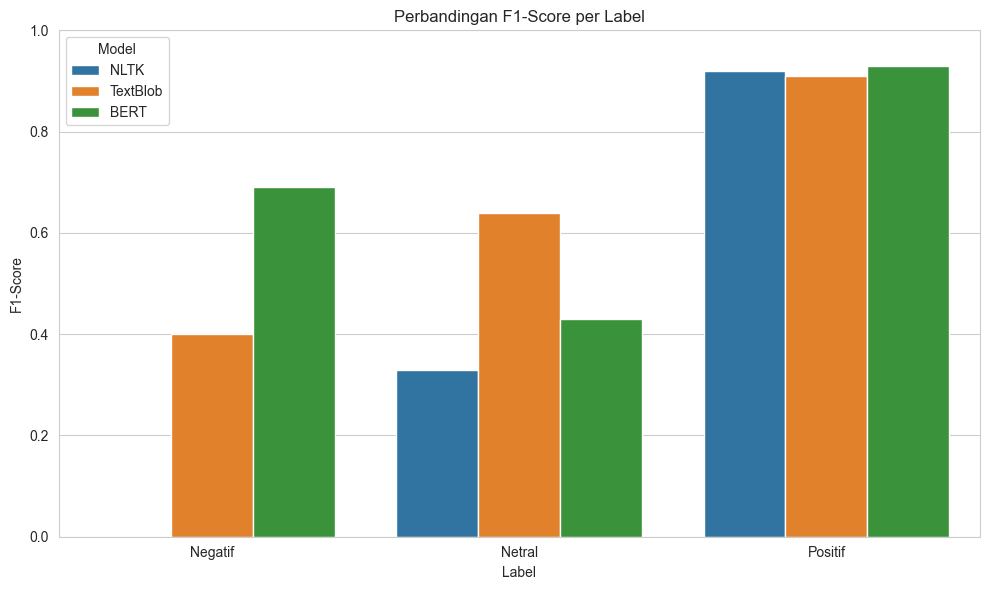

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=df_comparison, x='Label', y='F1-Score', hue='Model')
plt.title("Perbandingan F1-Score per Label")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


Dari hasil Labeling NLTK, Labeling TextBlob, dan Labeling BERD, hasil akurasi, recall, f1-score, dan precsion yang terbaik menggunakan Labeling BERD

✅Menangkap komentar negatif dan positif dengan baik — penting untuk mitigasi risiko

✅ F1-score konsisten tinggi di semua kelas

✅ Cocok untuk komentar yang panjang, sarkastik, atau tidak eksplisit

✅ Akurasi dan macro average lebih stabil dibanding model lain


##### 📌Analisis Lanjutan menggunakan BERD

Distribusi Sentimen Konsumen Berdasarkan Kategori Produk

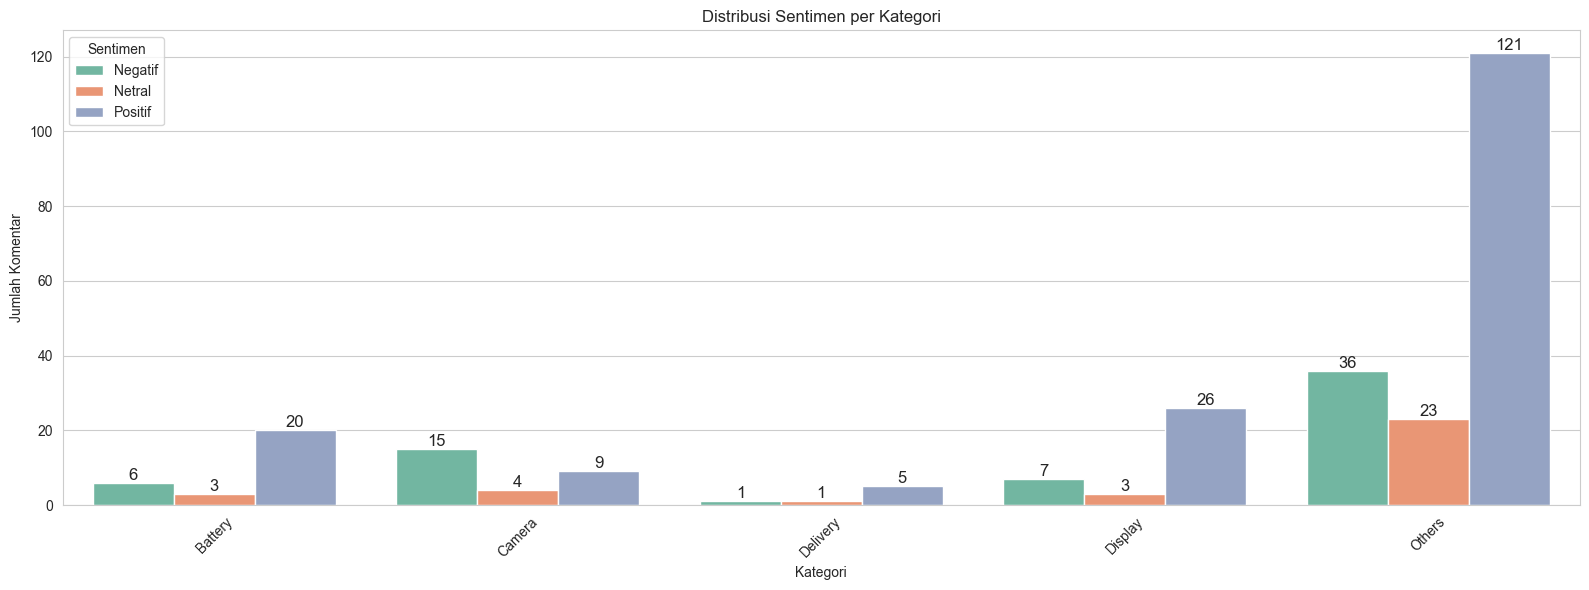

In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung jumlah sentimen per kategori dalam bentuk "long format"
df_plot = df_bert_clean.groupby(['Category', 'sentiment_label_text']).size().reset_index(name='Jumlah')

# Buat visualisasi barplot dengan label jumlah
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Plot
barplot = sns.barplot(
    data=df_plot,
    x='Category',
    y='Jumlah',
    hue='sentiment_label_text',
    palette='Set2'
)

# Tambahkan label angka di atas setiap bar
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(f'{int(height)}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=12)

# Judul dan label
plt.title("Distribusi Sentimen per Kategori")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Komentar")
plt.legend(title="Sentimen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mengidentifikasi kata-kata dominan pada komentar positif, negatif, dan netral

In [163]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Unduh resource NLTK (hanya sekali saja)
nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\71478\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\71478\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [164]:
def analyze_keywords_by_sentiment(df, sentiment_label_text, color='viridis'):
    # Filter komentar berdasarkan label
    comments = df[df['sentiment_label_text'] == sentiment_label_text]['Comments'].dropna().astype(str)

    # Gabungkan teks
    text = ' '.join(comments).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenisasi dan filter stopwords
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    # Hitung frekuensi kata
    word_freq = Counter(tokens)
    most_common = word_freq.most_common(20)

    # ===== WordCloud =====
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=color).generate_from_frequencies(word_freq)

    plt.figure(figsize=(12, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud Sentimen {sentiment_label_text}")
    plt.tight_layout()
    plt.show()

    # ===== Barplot =====
    df_freq = pd.DataFrame(most_common, columns=['Kata', 'Frekuensi'])
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_freq, x='Frekuensi', y='Kata', palette=color)
    plt.title(f"20 Kata Teratas - Sentimen {sentiment_label_text}")
    plt.xlabel("Jumlah Kemunculan")
    plt.ylabel("Kata")
    plt.tight_layout()
    plt.show()

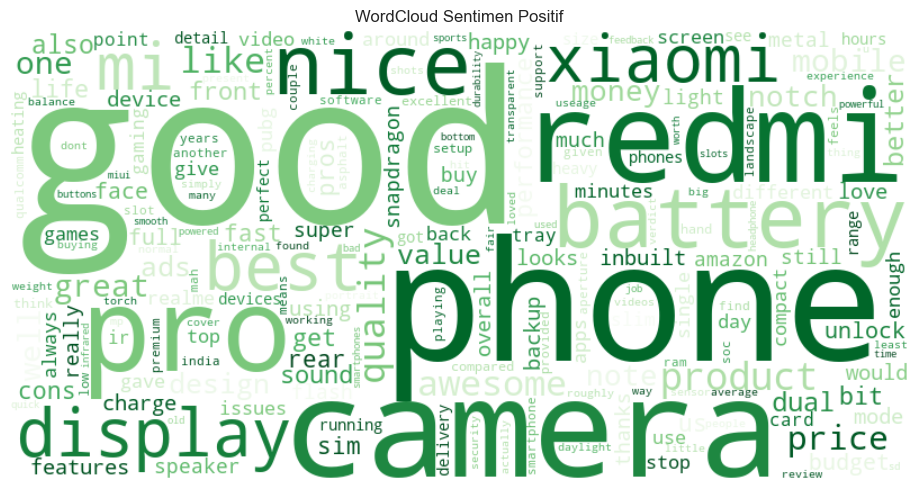

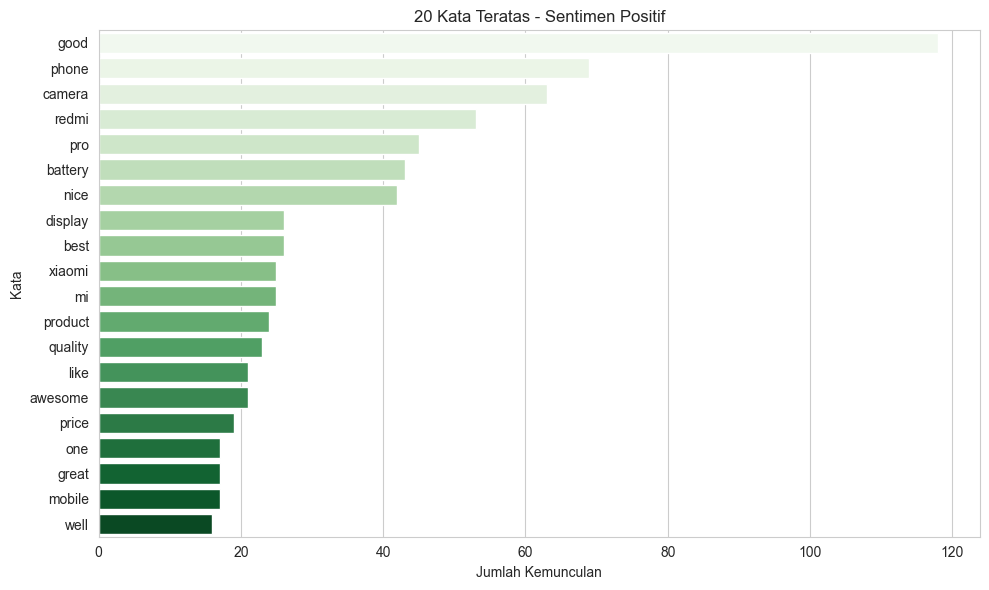

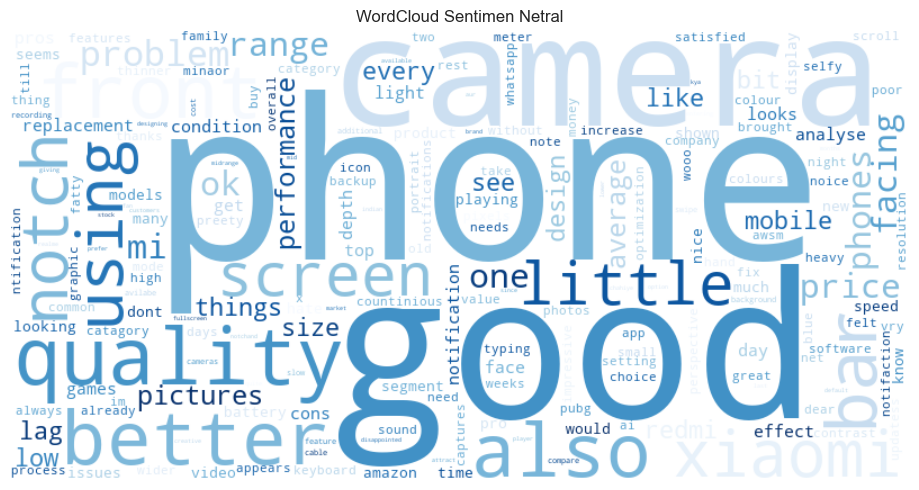

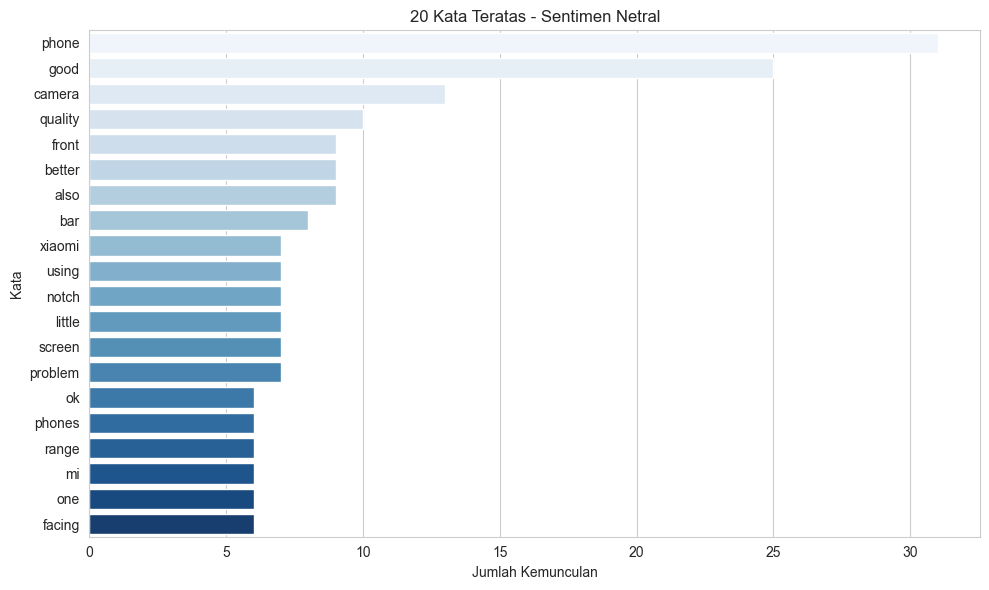

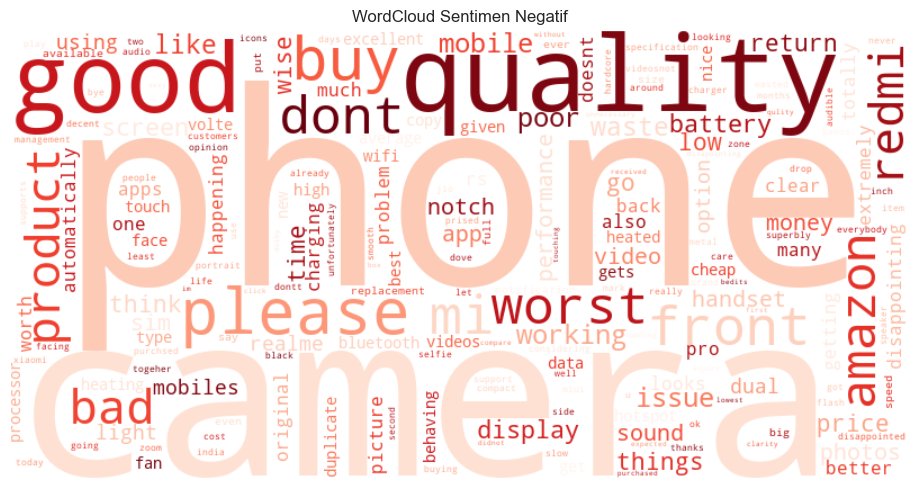

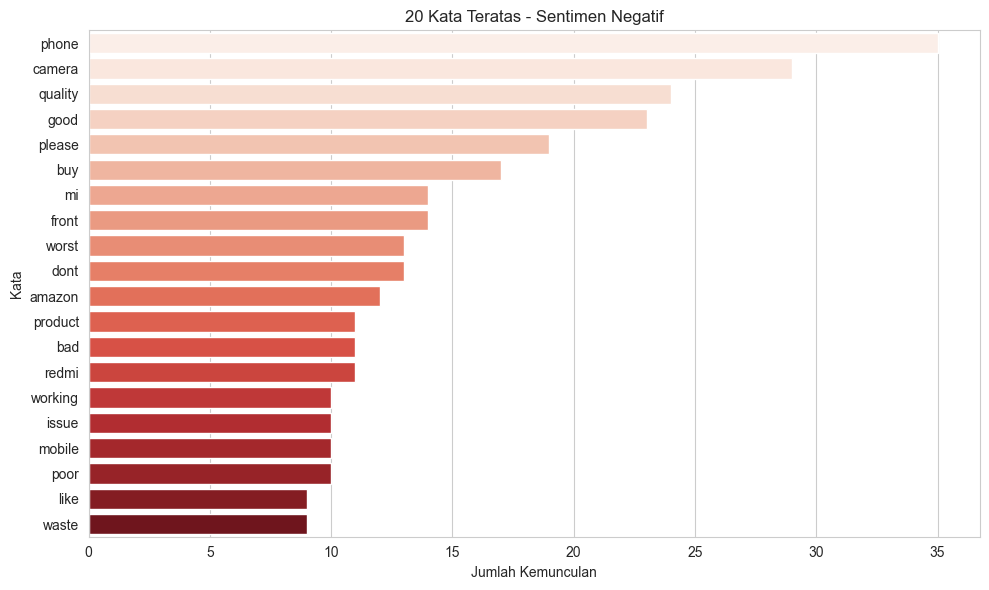

In [165]:
# Analisis kata-kata pada komentar POSITIF
analyze_keywords_by_sentiment(df_bert_clean, 'Positif', color='Greens')

# Analisis kata-kata pada komentar NETRAL
analyze_keywords_by_sentiment(df_bert_clean, 'Netral', color='Blues')

# Analisis kata-kata pada komentar NEGATIF
analyze_keywords_by_sentiment(df_bert_clean, 'Negatif', color='Reds')

Sentimen berdasarkan waktu (Trend Analysis)

Melihat apakah sentimen berubah seiring waktu

In [166]:
# Bersihkan dan ubah kolom Date jadi datetime
df_bert_clean['Date'] = pd.to_datetime(
    df_bert_clean['Date'].astype(str).str.replace('on ', ''), 
    format='%d %B %Y', errors='coerce'
)

In [167]:
# Hitung jumlah sentimen per hari
sentiment_trend_daily = df_bert_clean.groupby(['Date', 'sentiment_label_text']).size().unstack().fillna(0)
sentiment_trend_daily = sentiment_trend_daily.sort_index()  # urutkan berdasarkan tanggal

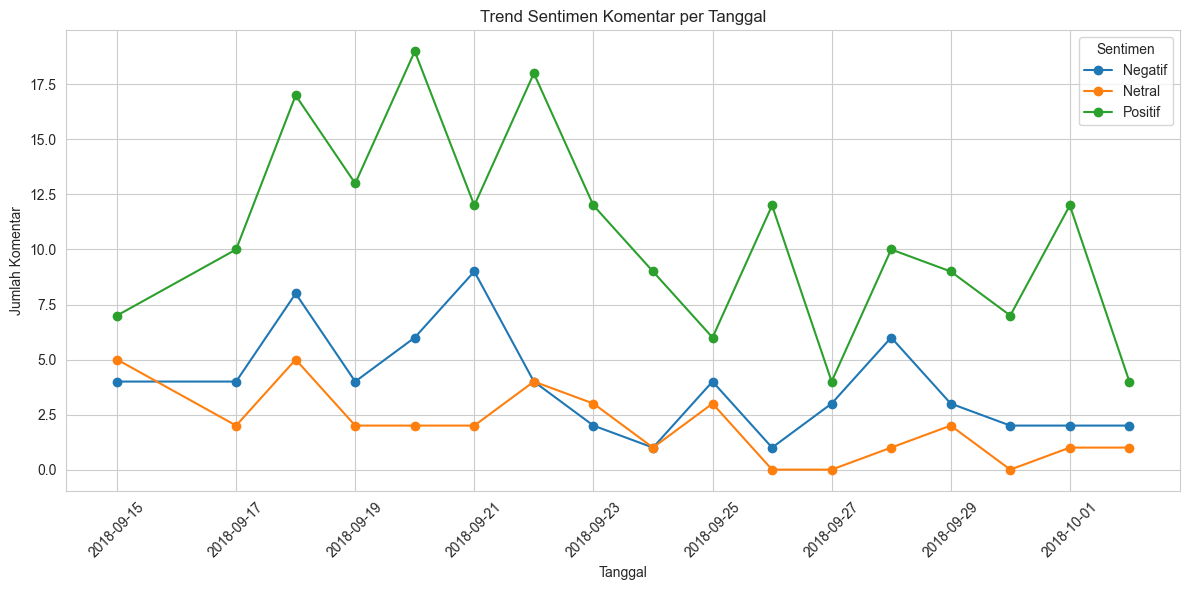

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for label in ['Negatif', 'Netral', 'Positif']:
    if label in sentiment_trend_daily.columns:
        plt.plot(sentiment_trend_daily.index, sentiment_trend_daily[label], marker='o', label=label)

plt.title("Trend Sentimen Komentar per Tanggal")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Komentar")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Sentimen")
plt.tight_layout()
plt.show()